In [1]:
# 1. 기본 데이터 처리
import pandas as pd
import numpy as np

# 2. 데이터 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import missingno as msno
%matplotlib inline

# 3. 데이터 전처리 및 데이터 분할
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# 4. 머신러닝 모델링 (회귀)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 5. 모델 최적화 및 평가
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 6. 모델 저장 및 환경 설정
import joblib
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# 81개 전체 컬럼 한글 의미 사전
col_desc = {
    "MSSubClass": "빌딩 등급 (층수, 시기 등)",
    "MSZoning": "토지 구획 (주거, 상업 등)",
    "LotFrontage": "도로와 맞닿은 길이 (피트)",
    "LotArea": "대지 면적 (제곱피트)",
    "Street": "도로 접근 방식 (자갈, 포장)",
    "Alley": "골목길 접근 방식",
    "LotShape": "부지 모양 (정기적, 불규칙적)",
    "LandContour": "지형의 평탄도",
    "Utilities": "이용 가능한 공공시설 (전기, 가스 등)",
    "LotConfig": "부지 구성 (코너, 막다른 길 등)",
    "LandSlope": "부지 경사도",
    "Neighborhood": "에임스 시 내의 구역명",
    "Condition1": "주변 도로/철도 인접 조건 1",
    "Condition2": "주변 도로/철도 인접 조건 2 (둘 이상일 때)",
    "BldgType": "주거 형태 (단독주택, 타운하우스 등)",
    "HouseStyle": "주거 스타일 (1층, 2층 등)",
    "OverallQual": "전반적인 재료 및 마감 품질 (1-10)",
    "OverallCond": "전반적인 상태 등급 (1-10)",
    "YearBuilt": "완공 연도",
    "YearRemodAdd": "리모델링 연도",
    "RoofStyle": "지붕 스타일",
    "RoofMatl": "지붕 재료",
    "Exterior1st": "외벽 재료 1",
    "Exterior2nd": "외벽 재료 2",
    "MasVnrType": "석재 외장(Masonry veneer) 유형",
    "MasVnrArea": "석재 외장 면적",
    "ExterQual": "외재 품질",
    "ExterCond": "외재 현재 상태",
    "Foundation": "기초 공사 토대 유형",
    "BsmtQual": "지하실 높이 (품질)",
    "BsmtCond": "지하실 일반 상태",
    "BsmtExposure": "지하실 노출 정도 (정원 등과 연결)",
    "BsmtFinType1": "지하실 마감 상태 1",
    "BsmtFinSF1": "지하실 마감 면적 1",
    "BsmtFinType2": "지하실 마감 상태 2",
    "BsmtFinSF2": "지하실 마감 면적 2",
    "BsmtUnfSF": "지하실 미완성 면적",
    "TotalBsmtSF": "지하실 총 면적",
    "Heating": "난방 방식",
    "HeatingQC": "난방 품질 및 상태",
    "CentralAir": "중앙 냉방 여부 (Y/N)",
    "Electrical": "전기 시스템",
    "1stFlrSF": "1층 면적",
    "2ndFlrSF": "2층 면적",
    "LowQualFinSF": "저품질 마감 면적 (모든 층)",
    "GrLivArea": "지상층 거주 면적 (총 넓이)",
    "BsmtFullBath": "지하실 전체 욕실 수",
    "BsmtHalfBath": "지하실 간이 욕실 수",
    "FullBath": "지상층 전체 욕실 수",
    "HalfBath": "지상층 간이 욕실 수",
    "BedroomAbvGr": "지상층 침실 수",
    "KitchenAbvGr": "지상층 주방 수",
    "KitchenQual": "주방 품질",
    "TotRmsAbvGrd": "지상층 총 방 수 (욕실 제외)",
    "Functional": "주택 기능성 등급",
    "Fireplaces": "벽난로 개수",
    "FireplaceQu": "벽난로 품질",
    "GarageType": "차고 위치",
    "GarageYrBlt": "차고 완공 연도",
    "GarageFinish": "차고 내부 마감",
    "GarageCars": "차고 수용 차량 대수",
    "GarageArea": "차고 면적",
    "GarageQual": "차고 품질",
    "GarageCond": "차고 상태",
    "PavedDrive": "포장 진입로 상태",
    "WoodDeckSF": "나무 데크 면적",
    "OpenPorchSF": "오픈 포치 면적",
    "EnclosedPorch": "폐쇄형 포치 면적",
    "3SsnPorch": "3계절 포치 면적",
    "ScreenPorch": "스크린 포치 면적",
    "PoolArea": "수영장 면적",
    "PoolQC": "수영장 품질",
    "Fence": "울타리 품질",
    "MiscFeature": "기타 특징 (엘리베이터 등)",
    "MiscVal": "기타 특징의 가치($)",
    "MoSold": "판매 월",
    "YrSold": "판매 연도",
    "SaleType": "판매 유형",
    "SaleCondition": "판매 조건",
    "SalePrice": "판매 가격 (Target)"
}

### 1단계: 데이터 훑어보기 (Data Exploration)
- df.head()로 상위 데이터 확인
- df.info()로 숫자형 vs 문자형 변수 구분
- df.describe()로 평균, 최솟값, 최댓값 파악

In [3]:
# 1. 데이터 로드
train = pd.read_csv('train.csv', index_col='Id')
test = pd.read_csv('test.csv', index_col='Id')

# 2. 나중에 다시 분리하기 위해 train의 행 개수를 저장해둡니다.
ntrain = train.shape[0] # 예: 1460
ntest = test.shape[0]   # 예: 1459

# 3. 타겟 변수(SalePrice)는 따로 보관하고 train에서 삭제합니다. (test에는 원래 없으니까요)
# y_train = np.log1p(train['SalePrice'])
y_train = train['SalePrice']
train.drop(['SalePrice'], axis=1, inplace=True)

# 4. [핵심] 두 데이터를 하나로 합칩니다. (위-아래로 붙이기)
# 이렇게 하면 전체 데이터에 대해 동일한 전처리(결측치, 인코딩)가 한 번에 적용됩니다.
data = pd.concat((train, test))
# all_data.drop(['Id'], axis=1, inplace=True) # 인덱스로 지정해서 삭제하면 안됨

print(f"합쳐진 데이터 크기: {data.shape}")

합쳐진 데이터 크기: (2919, 79)


In [6]:
data.head(3)
# data.info()
# data.describe()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal


### 2단계: 결측치(Null) 정복하기
- msno.matrix()로 비어있는 곳 시각화
- '원래 없는 것(None)'과 '누락된 것' 구분하기
- 범주형은 최빈값이나 'None', 수치형은 0이나 중앙값으로 채우기

In [4]:
# 결측치 계산
null_info = data.isnull().sum()
null_info = null_info[null_info > 0].sort_values(ascending=False)

# 데이터프레임으로 만들어서 한글 설명 붙이기
null_df = pd.DataFrame(null_info, columns=['Missing_Count'])
null_df['Description'] = null_df.index.map(col_desc)

print("--- 결측치가 있는 컬럼 상세 정보 ---")
display(null_df)

--- 결측치가 있는 컬럼 상세 정보 ---


,Missing_Count,Description
PoolQC,2909,수영장 품질
MiscFeature,2814,기타 특징 (엘리베이터 등)
Alley,2721,골목길 접근 방식
Fence,2348,울타리 품질
MasVnrType,1766,석재 외장(Masonry veneer) 유형
FireplaceQu,1420,벽난로 품질
LotFrontage,486,도로와 맞닿은 길이 (피트)
GarageFinish,159,차고 내부 마감
GarageQual,159,차고 품질
GarageCond,159,차고 상태


In [5]:
# ---------------------------------------------------------
# 5. [전처리 구간] 여기서 아까 했던 모든 작업을 수행합니다.
# ---------------------------------------------------------

# 1. [수치형 데이터] - 동네별 중앙값으로 채우기 (LotFrontage)
# 도로 길이는 동네 특성을 따라가므로 Neighborhood 그룹별 중앙값을 사용합니다.
data["LotFrontage"] = data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# 2. [수치형 데이터] - 0으로 채우기 (면적, 개수 관련)
# 수영장 면적이나 차고 면적이 결측치면 시설이 없다는 뜻이므로 0을 넣습니다.
for col in ('MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 
            'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 
            'GarageCars', 'GarageArea', 'GarageYrBlt'):
    data[col] = data[col].fillna(0)

# 3. [범주형 데이터] - 최빈값(가장 흔한 값)으로 채우기
# 데이터가 1~2개만 누락된 경우, 가장 많이 나타나는 값으로 채워줍니다.
for col in ('MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 
            'Exterior2nd', 'SaleType', 'Functional'):
    data[col] = data[col].fillna(data[col].mode()[0])

# 4. [특수 케이스] - 'None'으로 채우기 (앞서 요청하신 리스트 + 추가)
# 시설이 존재하지 않음을 명시적으로 표시합니다.
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
    'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtCond', 'BsmtQual', 'MasVnrType'
]
data[none_cols] = data[none_cols].fillna('None')

# 인코딩 하기 직전에! 남은 결측치를 가장 흔한 값으로 덮어쓰기
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# 5. 최종 확인
print("남은 결측치 수:", data.isnull().sum().sum())


from sklearn.preprocessing import LabelEncoder
# 문자열인 컬럼들만 골라서 숫자로 변환
cols = data.select_dtypes(include='object').columns
for c in cols:
    lbl = LabelEncoder() 
    data[c] = lbl.fit_transform(list(data[c].values))

# ---------------------------------------------------------
# 6. [분리 구간] 이제 다시 train과 test로 나눕니다.
# ---------------------------------------------------------
# 처음에 저장해둔 ntrain(행 개수)을 기준으로 자르면 정확합니다.
X_train = data[:ntrain].copy()     # 0부터 ntrain까지가 원래 train
X_test_real = data[ntrain:].copy()  # ntrain부터 끝까지가 원래 test
X_test_real.to_csv('X_test_real.csv', encoding='utf-8-sig', index=True)

print(f"복구된 Train 크기: {X_train.shape}") # (1460, 컬럼수)
print(f"복구된 Test 크기: {X_test_real.shape}")  # (1459, 컬럼수)

data = pd.concat([X_train, y_train], axis=1)

남은 결측치 수: 0
복구된 Train 크기: (1460, 79)
복구된 Test 크기: (1459, 79)


In [49]:
data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,3,65.0,8450,1,1,3,3,0,4,...,0,3,4,1,0,2,2008,8,4,208500
2,20,3,80.0,9600,1,1,3,3,0,2,...,0,3,4,1,0,5,2007,8,4,181500
3,60,3,68.0,11250,1,1,0,3,0,4,...,0,3,4,1,0,9,2008,8,4,223500
4,70,3,60.0,9550,1,1,0,3,0,0,...,0,3,4,1,0,2,2006,8,0,140000
5,60,3,84.0,14260,1,1,0,3,0,2,...,0,3,4,1,0,12,2008,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,3,62.0,7917,1,1,3,3,0,4,...,0,3,4,1,0,8,2007,8,4,175000
1457,20,3,85.0,13175,1,1,3,3,0,4,...,0,3,2,1,0,2,2010,8,4,210000
1458,70,3,66.0,9042,1,1,3,3,0,4,...,0,3,0,3,2500,5,2010,8,4,266500


### 3단계: 집값의 핵심 범인 찾기 (Correlation)
- SalePrice와 상관계수가 높은 Top 10 컬럼 뽑기
- 산점도(Scatter Plot)를 그려서 집값과 비례하는지 확인

<Axes: >

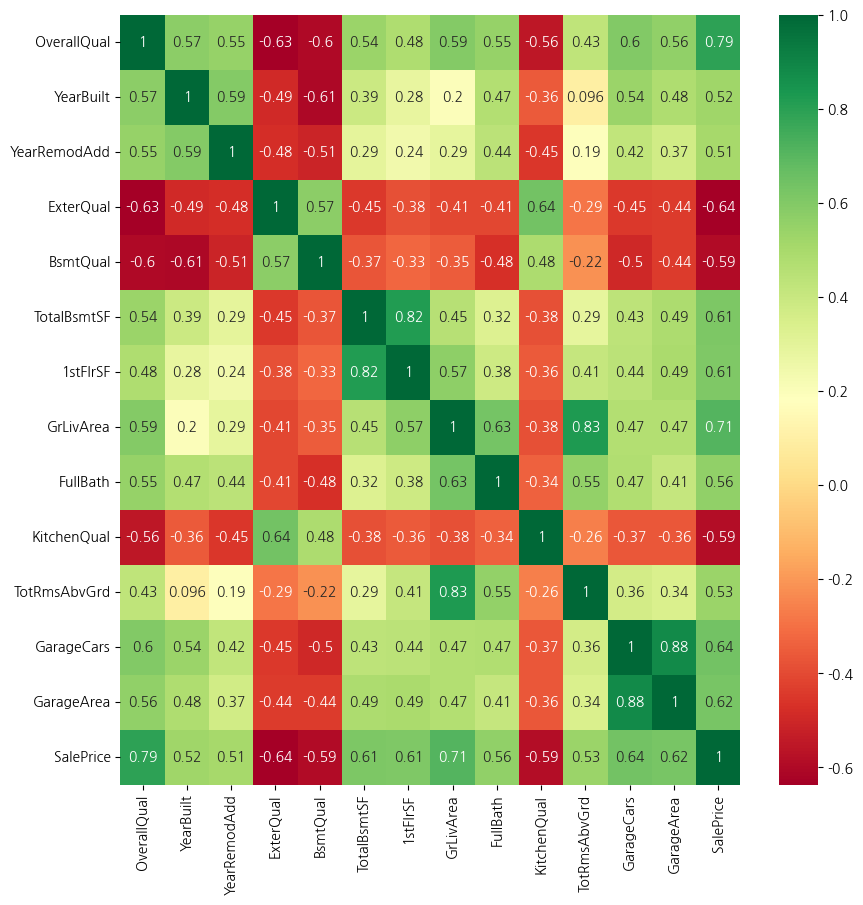

In [144]:
# 1. 모든 컬럼 간의 '친밀도(상관계수)'를 계산합니다.
# 1에 가까울수록 "너 오르면 나도 올라!" 하는 아주 친한 사이입니다.
corrmat = data.corr()

# 2. 'SalePrice'와 친한 정도만 쏙 뽑아냅니다.
# abs()는 마이너스 친밀도(가격 깎아먹는 범인)도 중요하니까 절대값을 씌운 거예요.
# 그중 친밀도가 0.5 이상인 '영향력 있는' 컬럼들의 이름(index)만 가져옵니다.
top_corr_features = corrmat.index[abs(corrmat["SalePrice"]) > 0.5]

# 3. 그 핵심 컬럼들끼리만 다시 관계를 그려봅니다. (히트맵)
plt.figure(figsize=(10,10))
# annot=True는 칸 안에 숫자를 써달라는 뜻이고, cmap은 색상 테마입니다.
sns.heatmap(data[top_corr_features].corr(), annot=True, cmap="RdYlGn")

### 4단계: 이상치(Outlier) 제거
- 땅은 엄청 넓은데 집값이 너무 싼 데이터 등 '이상한 놈' 골라내기

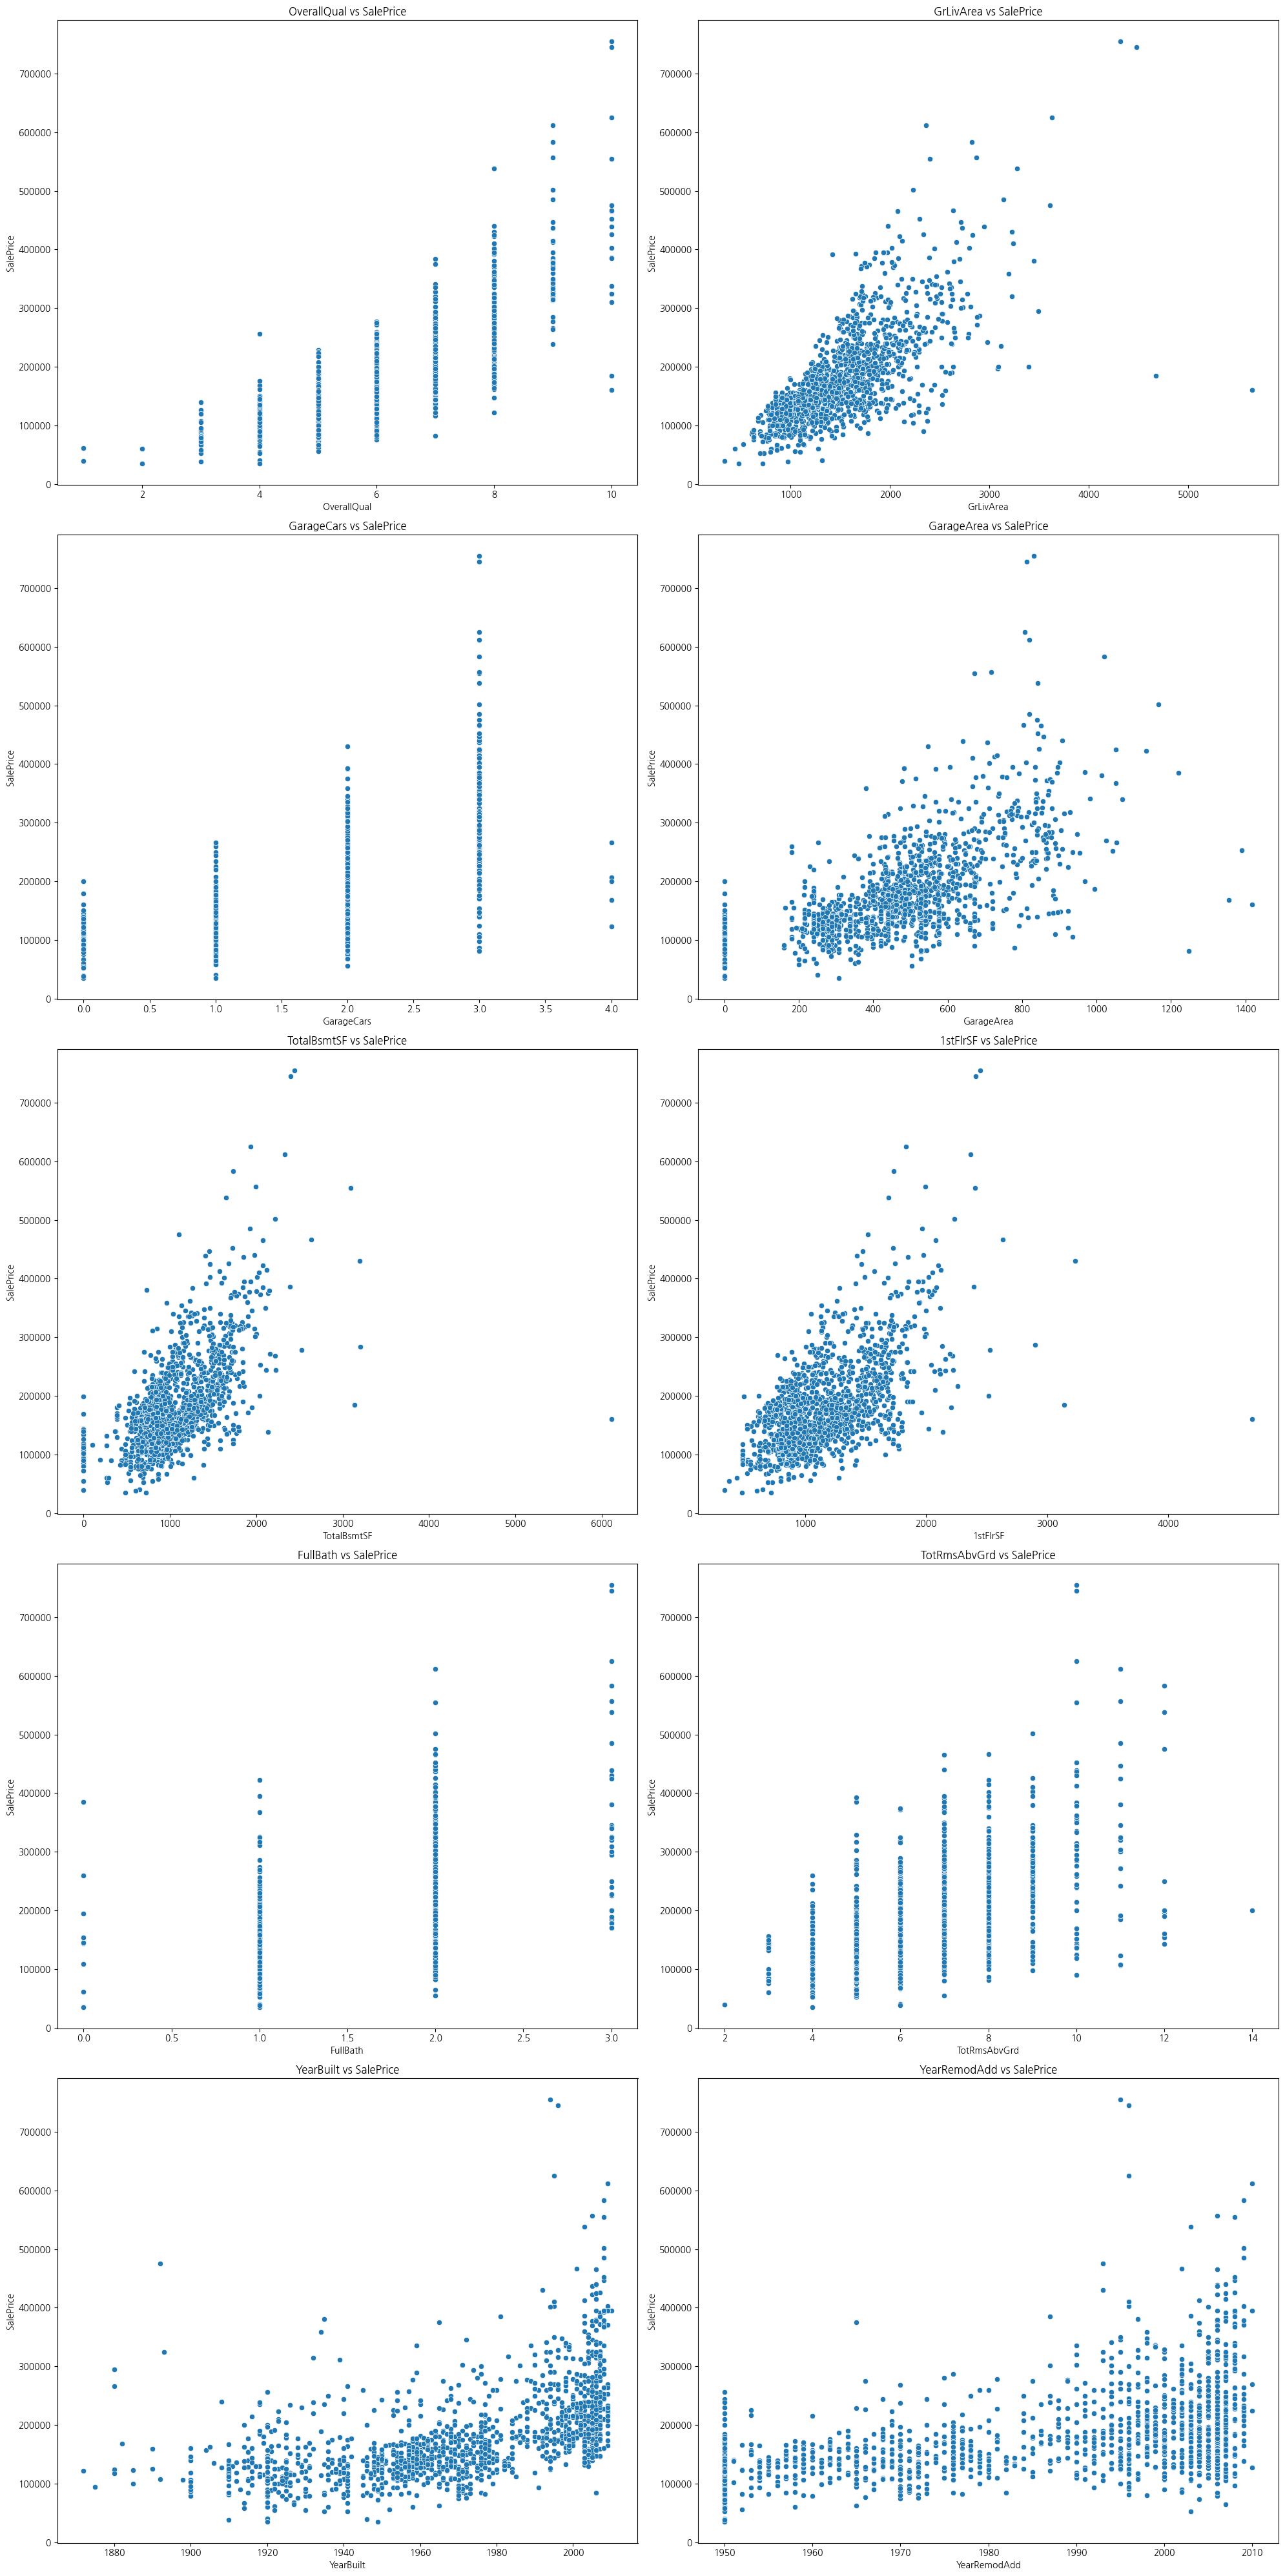

In [134]:

# 타겟(SalePrice)과 상관관계가 높은 상위 10개 변수 추출
corr = data.corr(numeric_only=True)
top_features = corr['SalePrice'].sort_values(ascending=False).index[1:11]

# 상위 변수들과 가격 간의 관계 시각화 (이상치 찾기용)
plt.figure(figsize=(20, 40))
for i, col in enumerate(top_features):
    plt.subplot(5, 2, i+1)
    sns.scatterplot(data=data, x=col, y='SalePrice')
    plt.title(f'{col} vs SalePrice')

plt.tight_layout()
plt.show()

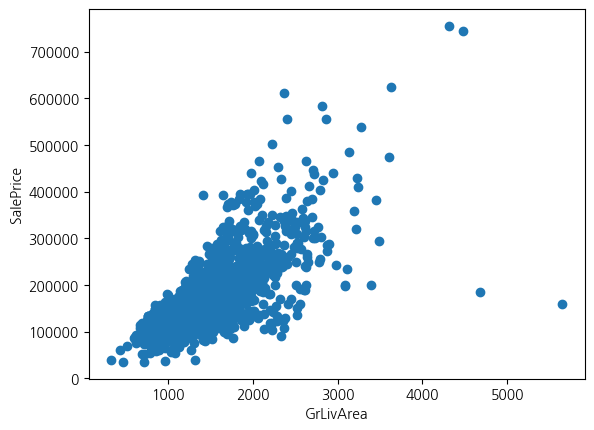

In [6]:
# 산점도 그리기
plt.scatter(x=data['GrLivArea'], y=data['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

# 면적은 4000 넘는데 가격은 300,000 미만인 하단 우측 데이터 삭제 (전형적인 이상치)
data = data.drop(data[(data['GrLivArea']>4000) & (data['SalePrice']<300000)].index)

삭제할 인덱스: Index([582, 1062, 1191], dtype='int64', name='Id')


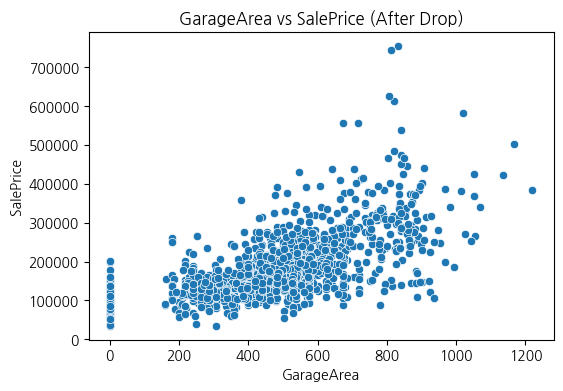

In [153]:
# # 1. GarageArea가 1200보다 크면서 SalePrice는 300,000 미만인 데이터 찾기
# outliers = data[(data['GarageArea'] > 1200) & (data['SalePrice'] < 300000)].index

# print(f"삭제할 인덱스: {outliers}")

# # 2. 해당 인덱스 삭제 (원본 데이터에서 제거)
# data = data.drop(outliers)

# # 3. (선택사항) 삭제 후 그래프 다시 그려서 확인
# plt.figure(figsize=(6, 4))
# sns.scatterplot(data=data, x='GarageArea', y='SalePrice')
# plt.title('GarageArea vs SalePrice (After Drop)')
# plt.show()

In [139]:
# 1. TotalBsmtSF(지하실) 이상치: 3,000 이상인데 가격은 300,000 미만인 경우
# 2. 1stFlrSF(1층) 이상치: 2,500 이상인데 가격은 300,000 미만인 경우
# (불러온 데이터프레임 변수명이 'asd'라고 가정합니다)

# drop_idx = data[
#     ((data['TotalBsmtSF'] > 3000) & (data['SalePrice'] < 300000)) | 
#     ((data['1stFlrSF'] > 2500) & (data['SalePrice'] < 300000))
# ].index

# print(f"추가로 삭제될 인덱스: {drop_idx}")

# # 삭제 실행
# data = data.drop(drop_idx)

# # 삭제 후 데이터 개수 확인
# print(f"남은 데이터 개수: {len(data)}")

추가로 삭제될 인덱스: Index([333, 530, 1025, 1045], dtype='int64', name='Id')
남은 데이터 개수: 1451


#### 5단계: 다양한 회귀 모델 학습 및 성능 평가
- 이 코드는 Ridge, Lasso, Random Forest, Gradient Boosting 4가지 모델을 동시에 돌리고 성적표를 만들어줍니다.

In [7]:
X = data.drop(['SalePrice'], axis=1)
# y = data['SalePrice']
y= np.log1p(data['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"학습용(X_train): {X_train.shape}")
print(f"검증용(X_test): {X_test.shape}")

학습용(X_train): (1166, 79)
검증용(X_test): (292, 79)


In [8]:
# 1. 평가 함수
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    actual = np.expm1(y_test)
    predictions = np.expm1(preds)
    
    mae = mean_absolute_error(actual, predictions)
    mse = mean_squared_error(actual, predictions)
    rmse = np.sqrt(mse)
    rmsle = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds) # 로그 변환된 값 기준의 R2
    
    return [mae, mse, rmse, rmsle, r2]

# 2. 모델 리스트 확장
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.001),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(learning_rate=0.05, max_depth=3, n_estimators=500, subsample=0.5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.5, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, colsample_bytree=0.5, num_leaves=5, random_state=42)
}

# 3. 학습 및 결과 도출
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = evaluate_model(model, X_test, y_test)

# 4. 결과 비교 표
df_res = pd.DataFrame(results, index=['MAE', 'MSE', 'RMSE', 'RMSLE', 'R2']).T
print(df_res.sort_values(by='RMSLE')) # 성적 좋은 순(RMSLE 낮은 순)으로 정렬

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3112
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 72
[LightGBM] [Info] Start training from score 12.023362
                           MAE           MSE          RMSE     RMSLE        R2
GradientBoosting  13827.227948  3.811579e+08  19523.265607  0.112915  0.924368
XGBoost           14218.613442  3.934742e+08  19836.184929  0.115948  0.920250
LightGBM          14361.400299  3.782294e+08  19448.120291  0.122346  0.911206
Lasso             14527.066058  4.232334e+08  20572.636134  0.126186  0.905545
Ridge             14756.349015  4.333902e+08  20818.025002  0.126293  0.905385
Linear            14684.212969  4.263713e+08  20648.760226  0.126981  0.904351
RandomForest      16445.880197  5.801980e

In [16]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 1등(GBM)과 2등(XGB)의 예측값 가져오기 (로그 변환된 상태)
gbm_log_preds = models['GradientBoosting'].predict(X_test)
xgb_log_preds = models['XGBoost'].predict(X_test)

# 2. 가중치 적용 (GBM 60%, XGB 40%)
# 비율은 0.7:0.3 이나 0.5:0.5로 바꿔보며 최적의 지점을 찾을 수 있습니다.
ensemble_log_preds = (gbm_log_preds * 0.7) + (xgb_log_preds * 0.3)

# 3. 평가를 위해 원래 가격 단위로 복원 (np.expm1)
actual_price = np.expm1(y_test)
ensemble_actual_preds = np.expm1(ensemble_log_preds)

# 4. 앙상블 점수 계산
ens_mae = mean_absolute_error(actual_price, ensemble_actual_preds)
ens_rmsle = np.sqrt(mean_squared_error(y_test, ensemble_log_preds)) # 로그 기준 오차
ens_r2 = r2_score(y_test, ensemble_log_preds)

# 5. 결과 출력
print("="*40)
print("🔥 [Top 2 가중치 앙상블 결과]")
print(f"비중: GradientBoosting(0.6) + XGBoost(0.4)")
print("-" * 40)
print(f"MAE  : {ens_mae:.2f}")
print(f"RMSLE: {ens_rmsle:.6f} (낮을수록 좋음)")
print(f"R2   : {ens_r2:.6f} (1에 가까울수록 좋음)")
print("="*40)

# 기존 GBM 단독 점수와 비교해보세요!

🔥 [Top 2 가중치 앙상블 결과]
비중: GradientBoosting(0.6) + XGBoost(0.4)
----------------------------------------
MAE  : 13585.50
RMSLE: 0.112303 (낮을수록 좋음)
R2   : 0.925186 (1에 가까울수록 좋음)


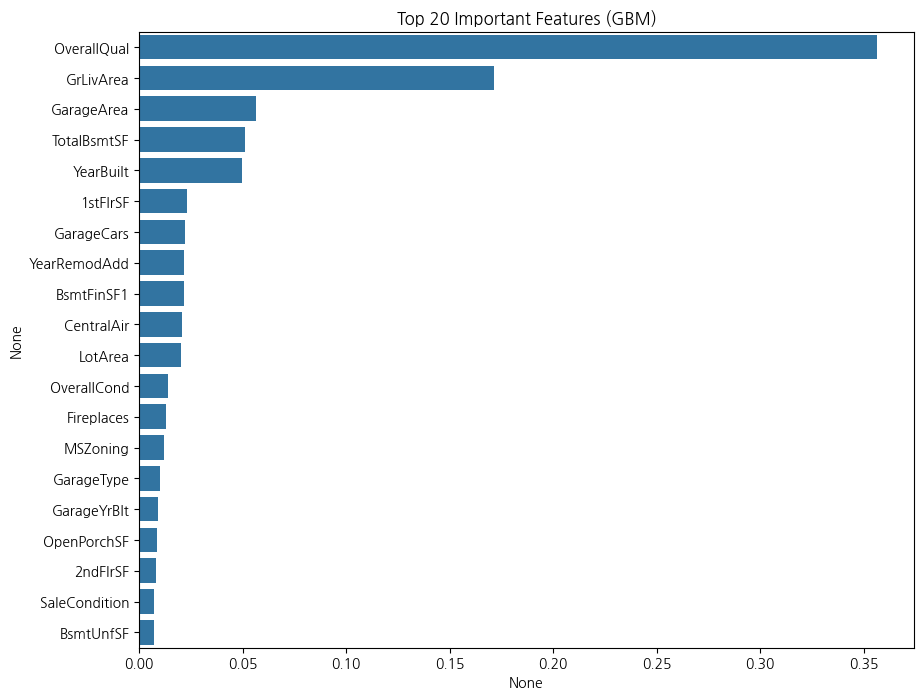

In [17]:
# 1등 모델(GBM)이 중요하게 생각하는 상위 20개 컬럼 확인
import matplotlib.pyplot as plt

importances = models['GradientBoosting'].feature_importances_
feature_names = X_train.columns
feature_series = pd.Series(data=importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_series[:20], y=feature_series.index[:20])
plt.title("Top 20 Important Features (GBM)")
plt.show()

In [19]:
xgb_preds = models['XGBoost'].predict(X_test)
lasso_preds = models['Lasso'].predict(X_test)
gb_preds = models['GradientBoosting'].predict(X_test)

# 세 모델의 예측값을 평균냄
ensemble_preds = (xgb_preds + lasso_preds + gb_preds) / 3

# 앙상블 평가 (evaluate_model 함수와 동일한 로직)
ens_actual = np.expm1(y_test)
ens_predictions = np.expm1(ensemble_preds)
ens_rmsle = np.sqrt(mean_squared_error(y_test, ensemble_preds))
ens_r2 = r2_score(y_test, ensemble_preds)

print(f"\n🔥 앙상블 결과 (XGB+Lasso+GBM) -> RMSLE: {ens_rmsle:.6f}, R2: {ens_r2:.6f}")


🔥 앙상블 결과 (XGB+Lasso+GBM) -> RMSLE: 0.112271, R2: 0.925228


### 3대 모델 정밀 튜닝 (GridSearchCV)
- 이 코드는 각 모델별로 가장 영향력이 큰 파라미터들만 골라서 최적의 조합을 찾아줍니다.

In [86]:
# 1. Lasso 튜닝: alpha(규제 강도)가 핵심입니다.
param_lasso = {'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01]}

# 2. XGBoost 튜닝: 트리 깊이와 학습률, 그리고 데이터 샘플링 비율이 중요합니다.
param_xgb = {
    'n_estimators': [500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.7, 0.9]
}

# 3. LightGBM 튜닝: XGB와 비슷하지만 속도가 빠르고 잎사귀(num_leaves) 중심입니다.
param_lgb = {
    'n_estimators': [500],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [20, 31], # 기본값이 31입니다.
    'feature_fraction': [0.7, 0.9]
}

# 튜닝용 헬퍼 함수
def tune_model(model, params):
    grid = GridSearchCV(model, params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"최적의 파라미터: {grid.best_params_}")
    return grid.best_estimator_

# 실행
print("--- Lasso 튜닝 시작 ---")
best_lasso = tune_model(Lasso(), param_lasso)

print("\n--- XGBoost 튜닝 시작 ---")
best_xgb = tune_model(XGBRegressor(random_state=42), param_xgb)

print("\n--- LightGBM 튜닝 시작 ---")
best_lgb = tune_model(LGBMRegressor(random_state=42), param_lgb)

--- Lasso 튜닝 시작 ---
최적의 파라미터: {'alpha': 0.0001}

--- XGBoost 튜닝 시작 ---
최적의 파라미터: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}

--- LightGBM 튜닝 시작 ---
최적의 파라미터: {'feature_fraction': 0.7, 'learning_rate': 0.05, 'n_estimators': 500, 'num_leaves': 20}


In [85]:
from sklearn.metrics import make_scorer

# 1. 튜닝할 모델 설정 (간결하게 필요한 것만)
models = {
    "GradientBoosting": (GradientBoostingRegressor(random_state=42), {
            "n_estimators": [100, 500],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }),
    "Lasso": (Lasso(max_iter=1000), {"alpha": [0.001, 0.002, 0.005]}),
    "XGBoost": (XGBRegressor(random_state=42), {
        "n_estimators": [500, 700],
        "learning_rate": [0.01, 0.03],
        "max_depth": [3, 5],
        "subsample": [0.5, 0.8]
    }),
    "LightGBM": (LGBMRegressor(random_state=42, verbose=-1), {
        "n_estimators": [500, 700],
        "learning_rate": [0.01, 0.03]
    })
}

# 2. 튜닝 실행 및 결과만 딱 출력
best_estimators = {}

for name, (model, params) in models.items():
    print(f"--- {name} 튜닝 시작 ---")
    # scoring='r2'로 잡으면 우리가 보기 편한 점수로 최적화합니다. 
    # (캐글 점수를 올리려면 타겟값에 np.log1p를 하고 돌리는 게 핵심입니다)
    grid = GridSearchCV(model, params, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_estimators[name] = grid.best_estimator_
    print(f"최적의 파라미터: {grid.best_params_}")
    print(f"R2 점수: {grid.best_score_:.4f}")
    print("-" * 30)

--- GradientBoosting 튜닝 시작 ---
최적의 파라미터: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500}
R2 점수: 0.8985
------------------------------
--- Lasso 튜닝 시작 ---
최적의 파라미터: {'alpha': 0.001}
R2 점수: 0.9011
------------------------------
--- XGBoost 튜닝 시작 ---
최적의 파라미터: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 700, 'subsample': 0.5}
R2 점수: 0.9077
------------------------------
--- LightGBM 튜닝 시작 ---
최적의 파라미터: {'learning_rate': 0.01, 'n_estimators': 700}
R2 점수: 0.8898
------------------------------


In [21]:
# 1. 각 모델의 최적 설정값으로 모델 정의 (질문자님 성적 기반)
model_gb = GradientBoostingRegressor(learning_rate=0.05, max_depth=3, n_estimators=500, subsample=0.6, random_state=42)
model_xgb = XGBRegressor(learning_rate=0.05, max_depth=3, n_estimators=500, subsample=0.5, random_state=42)
# model_gbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, colsample_bytree=0.5, num_leaves=5, random_state=42)
model_lasso = Lasso(alpha=0.001)

# 2. 모델 학습
model_gb.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)
# model_gbm.fit(X_train, y_train)
model_lasso.fit(X_train, y_train)

# 3. 예측값 추출
pred_gb = model_gb.predict(X_test)
pred_xgb = model_xgb.predict(X_test)
# pred_gbm = model_gbm.predict(X_test)
pred_lasso = model_lasso.predict(X_test)

# 4. 가중치 섞기 (앙상블)
# 성적 1등(GB)에 50%, 2등(XGB)에 30%, 3등(gbm)에 20% 비중
final_ensemble_pred = (pred_gb * 0.6) + (pred_xgb * 0.3) + (pred_lasso * 0.1)

# 5. 최종 성능 확인
from sklearn.metrics import mean_squared_error
# final_rmsle = np.sqrt(mean_squared_error(y_test, final_ensemble_pred))
# print(f"앙상블 최종 RMSLE: {final_rmsle:.4f}")

ens_rmsle = np.sqrt(mean_squared_error(y_test, final_ensemble_pred))
ens_r2 = r2_score(y_test, final_ensemble_pred)

print(f"\n🔥 앙상블 결과 (XGB+Lasso+GBM) -> RMSLE: {ens_rmsle:.6f}, R2: {ens_r2:.6f}")


🔥 앙상블 결과 (XGB+Lasso+GBM) -> RMSLE: 0.112134, R2: 0.925411
